# Imports 

In [1]:
import sys
print("Python version:", sys.version)

Python version: 3.10.6 | packaged by conda-forge | (main, Aug 22 2022, 20:36:39) [GCC 10.4.0]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader

print("Pytorch GPU loaded") if torch.cuda.is_available() else print("Pytorch CPU loaded!")

from torchvision import transforms as T

import timm # TIMM(pyTorch IMage Models) => Contains SOTA models for image recognition 

Pytorch GPU loaded


![](Untitled-design.png)

# Configurations

In [3]:
from pathlib import Path

TRAIN_CSV = Path("data/train.csv")
VALID_CSV = Path("data/valid.csv")

In [4]:
BATCH_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
MODEL_NAME = "efficientnet_b0"
LR = 0.001
EPOCHS = 15

In [6]:
df_train = pd.read_csv(TRAIN_CSV)
df_train.head()

,0,1,2,3,4,5,6,7,8,9,...,8183,8184,8185,8186,8187,8188,8189,8190,8191,labels
0,0.631373,0.623529,0.713726,0.705882,0.658824,0.666667,0.654902,0.635294,0.647059,0.705882,...,0.611765,0.650980,0.658824,0.600000,0.603922,0.654902,0.694118,0.658824,0.666667,Squiggle
1,0.725490,0.752941,0.749020,0.701961,0.690196,0.721569,0.709804,0.745098,0.654902,0.721569,...,0.698039,0.721569,0.686275,0.713726,0.682353,0.690196,0.698039,0.701961,0.725490,Squiggle
2,0.717647,0.701961,0.713726,0.733333,0.705882,0.717647,0.725490,0.682353,0.717647,0.674510,...,0.694118,0.705882,0.682353,0.639216,0.713726,0.670588,0.678431,0.737255,0.674510,Squiggle
3,0.705882,0.674510,0.654902,0.678431,0.666667,0.662745,0.678431,0.662745,0.686275,0.686275,...,0.662745,0.631373,0.643137,0.705882,0.662745,0.705882,0.666667,0.654902,0.631373,Squiggle
4,0.647059,0.729412,0.701961,0.674510,0.611765,0.698039,0.713726,0.662745,0.701961,0.674510,...,0.670588,0.705882,0.674510,0.721569,0.694118,0.674510,0.705882,0.749020,0.729412,Squiggle


In [7]:
df_valid = pd.read_csv(VALID_CSV)
df_valid.head()

,0,1,2,3,4,5,6,7,8,9,...,8183,8184,8185,8186,8187,8188,8189,8190,8191,labels
0,0.686275,0.725490,0.737255,0.694118,0.658824,0.674510,0.643137,0.752941,0.678431,0.654902,...,0.709804,0.643137,0.674510,0.682353,0.658824,0.741176,0.658824,0.705882,0.701961,Squiggle
1,0.615686,0.631373,0.705882,0.678431,0.698039,0.639216,0.619608,0.654902,0.678431,0.682353,...,0.674510,0.674510,0.721569,0.709804,0.666667,0.619608,0.709804,0.705882,0.682353,Squiggle
2,0.670588,0.690196,0.698039,0.647059,0.650980,0.670588,0.721569,0.701961,0.647059,0.678431,...,0.670588,0.682353,0.698039,0.662745,0.619608,0.650980,0.662745,0.717647,0.650980,Squiggle
3,0.682353,0.650980,0.682353,0.670588,0.690196,0.701961,0.721569,0.709804,0.690196,0.650980,...,0.737255,0.733333,0.717647,0.674510,0.678431,0.745098,0.705882,0.709804,0.717647,Squiggle
4,0.647059,0.690196,0.717647,0.666667,0.654902,0.639216,0.654902,0.674510,0.682353,0.674510,...,0.682353,0.698039,0.705882,0.662745,0.678431,0.682353,0.725490,0.670588,0.658824,Squiggle


In [8]:
print(f"No. of examples present in df_train : {len(df_train)}")
print(f"No. of examples present in df_valid : {len(df_valid)}")
print(f"Labels are : {df_train['labels'].unique()}")

No. of examples present in df_train : 3200
No. of examples present in df_valid : 800
Labels are : ['Squiggle' 'Narrowbanddrd' 'Noises' 'Narrowband']


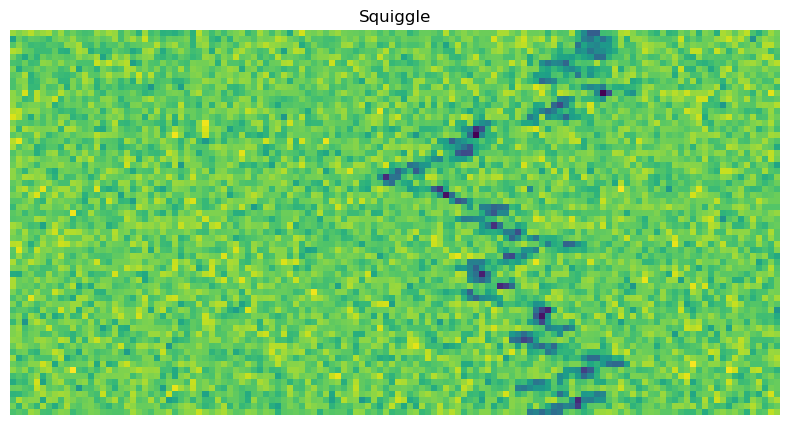

In [9]:
# Converting a sample image (presented as a row) into 2d representation
idx = 2

img_pixels = np.array(df_train.iloc[idx, 0:-2], dtype=np.float64) # Last column is label
img_label = df_train.iloc[idx, -1]

img_grid = np.resize(img_pixels, (64, 128)) # 64 * 128 = 8192

fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(img_grid)
ax.set_title(img_label)
ax.axis("off")
plt.show()

# Declare Spec Augmentations 

![](image6.png)

Vertical blank strips of noise => **TIME MASKS**
Horizontal strips => **FREQUENCY MASKS**

In [10]:
from spec_augment import TimeMask, FreqMask

In [11]:
# To compose a set of random transformations to be applied on an image dataset, we use pytorch's `torchvision.transform.Compose([...])` object

def get_train_transform():
    return T.Compose([
        TimeMask(T=15, num_masks=4), # T is width of VERTICAL mask here
        FreqMask(F=15, num_masks=3), # F is width of HORIZONTAL mask here
    ])

# Create Custom Dataset 

In [12]:
class SpecDataset(Dataset):
    """
    Class inheriting from PyTorch's torch.utils.data.Dataset class to build Spectogram augmentations & visualisations easily.
    Image must be 64 * 128!
    """
    def __init__(self, df: pd.DataFrame, augmentations=None):
        self.df = df.copy(deep=True)
        self.augmentations=augmentations
        # label_encoding
        label_mapper = {
            "Squiggle": 0,
            "Narrowband": 1,
            "Narrowbanddrd": 2,
            "Noises": 3
        }
        self.df.iloc[:, -1] = self.df.iloc[:, -1].map(label_mapper)

    def __len__(self) -> int:
        return len(self.df)

    def head(self) -> pd.DataFrame:
        return self.df.head()

    def __getitem__(self, idx: int):
        """
        VERY IMPORTANT: This converts 1D pandas Series records into 2D spectrogram images!
        """
        row: pd.Series = self.df.iloc[idx]
        
        img_pixels = np.array(row.iloc[0:-2], dtype=np.float64) # Last column is label
        img_label = np.array(row.iloc[-1], dtype=np.int64)
        
        img_grid = np.resize(img_pixels, (64, 128, 1)) # (height, width, channel)

        # Converting to a PyTorch tensor with dims (channel, height, width), as this is the format with PyTorch
        img = torch.Tensor(img_grid).permute(2, 0, 1)

        if self.augmentations != None:
            img = self.augmentations(img)
        
        return img.float(), img_label

In [13]:
trainset = SpecDataset(df_train, augmentations=get_train_transform())
validset = SpecDataset(df_valid, augmentations=None)

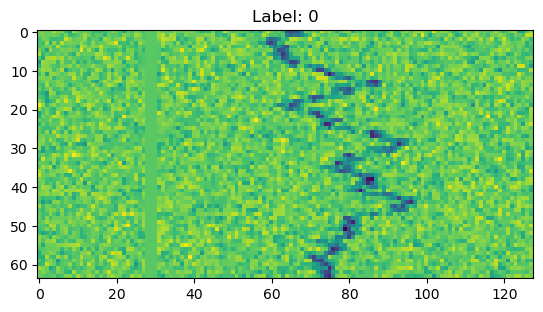

In [14]:
# TESTING trainset output - Everytime we run this cell, new augmentation applied!
image, label = trainset[591]

plt.imshow(image.permute(0, 1, 2).squeeze())
plt.title(f"Label: {label}")
plt.show()

# Load dataset into Batches

In [15]:
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
validloader = DataLoader(validset, batch_size=BATCH_SIZE)

In [16]:
print(f"Total no. of batches in trainloader : {len(trainloader)}")
print(f"Total no. of batches in validloader : {len(validloader)}")

Total no. of batches in trainloader : 25
Total no. of batches in validloader : 7


In [17]:
for images, labels in trainloader:
    break

print(f"One image batch shape : {images.shape}")
print(f"One label batch shape : {labels.shape}")

One image batch shape : torch.Size([128, 1, 64, 128])
One label batch shape : torch.Size([128])


# Load Model

In [18]:
class SpecModel(nn.Module):
    """
    Loading EfficientNet using timm
    """
    def __init__(self):
        super(SpecModel, self).__init__()
        self.net = timm.create_model(MODEL_NAME, num_classes=4, pretrained=True, in_chans=1) # 1 input channel

    def forward(self, images, labels=None):
        logits = self.net(images) # No softmax activation yet
        if labels != None:
            loss = nn.CrossEntropyLoss() # Callable loss object defined as class in torch.nn
            return logits, loss(logits, labels)
        else:
            return logits

In [19]:
model = SpecModel().to(DEVICE)
model

SpecModel(
  (net): EfficientNet(
    (conv_stem): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw): Conv2d(3

# Create Train and Eval Function

In [20]:
from tqdm.notebook import tqdm
from utils import multiclass_accuracy

In [21]:
def train_fn(model: nn.Module, dataloader: DataLoader, optimizer: optim.Optimizer, current_epoch: int) -> tuple[float, float]:
    model.train()
    total_loss = 0.0
    total_accuracy = 0.0
    progress_bar = tqdm(dataloader, desc=f"EPOCH[TRAIN] {str(current_epoch+1)}/{str(EPOCHS)}")

    for t, data in enumerate(progress_bar):
        # Load images & data into CPU/GPU(cuda)
        images, labels = data
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad() # Initialise gradients as zero
        logits, loss = model(images, labels) # FORWARD PASS
        loss.backward() # BACKPROPAGATION
        optimizer.step() # PREPARE FOR NEXT ITERATION

        total_loss += loss
        total_accuracy += multiclass_accuracy(logits, labels)

        # Adding current batch loss & accuracy to progress bar
        progress_bar.set_postfix({
            "batch loss": f"{float(total_loss / t+1) :6f}",
            "batch accuracy": f"{float(total_accuracy / t+1) :6f}"
        })

    # Return avg loss & accuracy across all batches
    return total_loss / len(dataloader), total_accuracy / len(dataloader)

In [22]:
def eval_fn(model: nn.Module, dataloader: DataLoader, current_epoch: int) -> tuple[float, float]:
    model.eval() # During validation, drop-out & BatchNorm will be off
    total_loss = 0.0
    total_accuracy = 0.0
    progress_bar = tqdm(dataloader, desc=f"EPOCH[VALID] {str(current_epoch+1)}/{str(EPOCHS)}")

    with torch.no_grad(): # NOT NECESSARY - just makes sure there is no gradient computation
        for t, data in enumerate(progress_bar):
            # Load images & data into CPU/GPU(cuda)
            images, labels = data
            images, labels = images.to(DEVICE), labels.to(DEVICE)
    
            logits, loss = model(images, labels)
            
            total_loss += loss
            total_accuracy += multiclass_accuracy(logits, labels)
    
            # Adding current batch loss & accuracy to progress bar
            progress_bar.set_postfix({
                "batch loss": f"{float(total_loss / t+1) :6f}",
                "batch accuracy": f"{float(total_accuracy / t+1) :6f}"
            })

    # Return avg loss & accuracy across all batches
    return total_loss / len(dataloader), total_accuracy / len(dataloader)

# Training Loop 

In [23]:
def fit(model: nn.Module, trainloader: DataLoader, validloader: DataLoader, optimizer: optim.Optimizer):
    """
    Saves model with least loss
    """
    best_valid_loss = np.inf
    for i in range(EPOCHS):
        train_loss, train_acc = train_fn(model, trainloader, optimizer, i)
        valid_loss, valid_acc = eval_fn(model, validloader, i)
        if valid_loss < best_valid_loss:
            torch.save(model.state_dict(), MODEL_NAME + "-best-weights.pt")
            print("Saved model with best weights!")
            best_valid_loss = valid_loss

In [24]:
optimizer = optim.Adam(model.parameters(), lr=LR)

In [25]:
# TRAIN MODEL ON GPU
fit(model, trainloader, validloader, optimizer)

EPOCH[TRAIN] 1/15:   0%|          | 0/25 [00:00<?, ?it/s]

/tmp/ipykernel_70189/3689942687.py:22: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1772252368025/work/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  "batch loss": f"{float(total_loss / t+1) :6f}",


TypeError: 'NoneType' object is not callable

# Inference 

In [4]:
from utils import view_classify